In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import os

pd.set_option('display.max_columns', None)
print("ВИЗУАЛИЗАЦИЯ И ОБУЧЕНИЕ МОДЕЛИ")


ВИЗУАЛИЗАЦИЯ И ОБУЧЕНИЕ МОДЕЛИ


In [3]:
print("выгрузка и первичный анализ")

#Загружаем данные
df = pd.read_csv('C:/Users/Redmi/Desktop/practise2026/data/raw/ai_student_impact_dataset (1).csv') 

print(f"\n Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")

выгрузка и первичный анализ

 Данные загружены: 50000 строк, 16 столбцов


In [4]:

print("ОТБОР ПРИЗНАКОВ И КОДИРОВАНИЕ")


# признаки
features = [
    'Weekly_GenAI_Hours',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Tool_Diversity',
    'Traditional_Study_Hours',
    'Perceived_AI_Dependency',
    'Institutional_Policy',
    'Anxiety_Level_During_Exams',
    'Major_Category',
    'Year_of_Study'
]

X = df[features].copy()
y = df['Burnout_Risk_Level'].copy()

print(f" Отобрано {len(features)} признаков")
print(f"   Признаки: {', '.join(features)}")

#кодируем категориальные признаки
print("\n Кодирование категориальных признаков")
encoders = {}

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le
    print(f" {col} закодирован")

#кодируем целевую переменную
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

print(f"\n Целевая переменная закодирована")
print(f"   Соответствие: {dict(zip(le_y.classes_, le_y.transform(le_y.classes_)))}")

#Проверка
print("\n--- Первые 5 строк после кодирования ---")
print(X.head())



ОТБОР ПРИЗНАКОВ И КОДИРОВАНИЕ
 Отобрано 10 признаков
   Признаки: Weekly_GenAI_Hours, Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity, Traditional_Study_Hours, Perceived_AI_Dependency, Institutional_Policy, Anxiety_Level_During_Exams, Major_Category, Year_of_Study

 Кодирование категориальных признаков
 Primary_Use_Case закодирован
 Prompt_Engineering_Skill закодирован
 Institutional_Policy закодирован
 Major_Category закодирован
 Year_of_Study закодирован

 Целевая переменная закодирована
   Соответствие: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

--- Первые 5 строк после кодирования ---
   Weekly_GenAI_Hours  Primary_Use_Case  Prompt_Engineering_Skill  \
0               23.31                 0                         1   
1                1.12                 3                         0   
2               21.26                 4                         1   
3                1.82                 0                         2   
4                9.29    

C:\Users\Redmi\AppData\Local\Temp\ipykernel_17188\4208160809.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


ВИЗУАЛИЗАЦИЯ СВЯЗЕЙ ПРИЗНАКОВ С ВЫГОРАНИЕМ


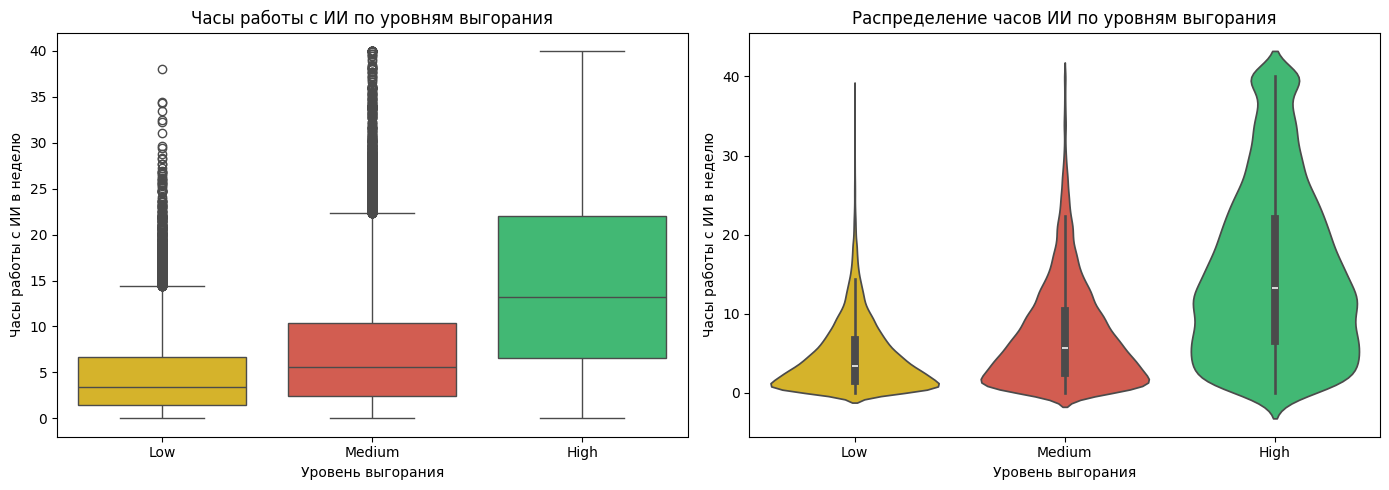

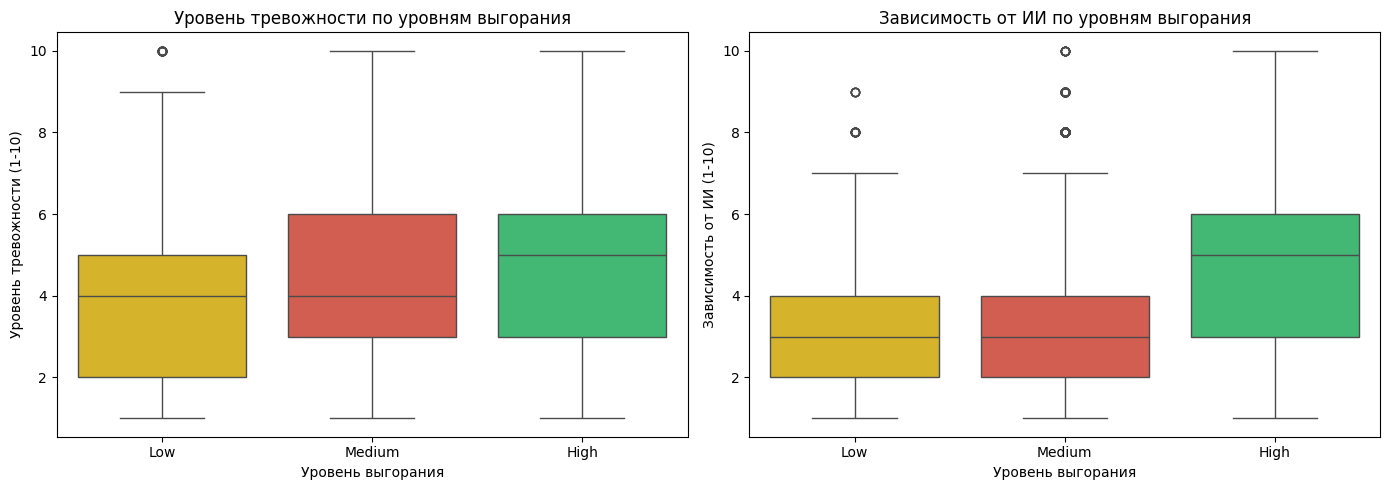

In [5]:

print("ВИЗУАЛИЗАЦИЯ СВЯЗЕЙ ПРИЗНАКОВ С ВЫГОРАНИЕМ")

df_viz = X.copy()
df_viz['Burnout'] = y # метки Low/Medium/High

# График 1: Часы с ИИ vs Выгорание 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x='Burnout', 
    y='Weekly_GenAI_Hours', 
    data=df_viz,
    order=['Low', 'Medium', 'High'],
    hue='Burnout',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Часы работы с ИИ по уровням выгорания', fontsize=12)
axes[0].set_xlabel('Уровень выгорания')
axes[0].set_ylabel('Часы работы с ИИ в неделю')

sns.violinplot(
    x='Burnout', 
    y='Weekly_GenAI_Hours', 
    data=df_viz,
    order=['Low', 'Medium', 'High'],
    hue='Burnout',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Распределение часов ИИ по уровням выгорания', fontsize=12)
axes[1].set_xlabel('Уровень выгорания')
axes[1].set_ylabel('Часы работы с ИИ в неделю')

plt.tight_layout()
plt.savefig('C:/Users/Redmi/Desktop/practise2026/data/result/ai_hours_vs_burnout.png', dpi=300)
plt.show()

# График 2: Тревожность и Зависимость от ИИ vs Выгорание
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Тревожность
sns.boxplot(
    x='Burnout', 
    y='Anxiety_Level_During_Exams', 
    data=df_viz,
    order=['Low', 'Medium', 'High'],
    hue='Burnout',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Уровень тревожности по уровням выгорания', fontsize=12)
axes[0].set_xlabel('Уровень выгорания')
axes[0].set_ylabel('Уровень тревожности (1-10)')

# Зависимость от ИИ
sns.boxplot(
    x='Burnout', 
    y='Perceived_AI_Dependency', 
    data=df_viz,
    order=['Low', 'Medium', 'High'],
    hue='Burnout',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Зависимость от ИИ по уровням выгорания', fontsize=12)
axes[1].set_xlabel('Уровень выгорания')
axes[1].set_ylabel('Зависимость от ИИ (1-10)')

plt.tight_layout()
plt.savefig('C:/Users/Redmi/Desktop/practise2026/data/result/anxiety_dependency_vs_burnout.png', dpi=300)
plt.show()


In [6]:

print("ОБУЧЕНИЕ МОДЕЛИ")


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Данные разделены:")
print(f"   Обучающая: {X_train.shape[0]} строк ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Тестовая: {X_test.shape[0]} строк ({X_test.shape[0]/len(X)*100:.1f}%)")

model = GaussianNB()
model.fit(X_train, y_train)
print(" Модель обучилась:")

y_pred = model.predict(X_test)
print(f"   Первые 10 предсказаний: {y_pred[:10]}")
print(f"   Первые 10 реальных: {y_test[:10]}")



ОБУЧЕНИЕ МОДЕЛИ
Данные разделены:
   Обучающая: 40000 строк (80.0%)
   Тестовая: 10000 строк (20.0%)
 Модель обучилась:
   Первые 10 предсказаний: [2 1 1 1 0 2 0 0 2 2]
   Первые 10 реальных: [2 2 1 2 0 0 0 0 2 0]


ОЦЕНКА КАЧЕСТВА МОДЕЛИ
Точность модели (Accuracy): 0.4909 (49.09%)
Baseline (угадывание частого класса): 0.4229 (42.29%)
Модель лучше baseline на: 16.1%

Отчёт по каждому классу
              precision    recall  f1-score   support

        High       0.64      0.44      0.52      2497
         Low       0.45      0.71      0.55      3274
      Medium       0.47      0.35      0.40      4229

    accuracy                           0.49     10000
   macro avg       0.52      0.50      0.49     10000
weighted avg       0.51      0.49      0.48     10000



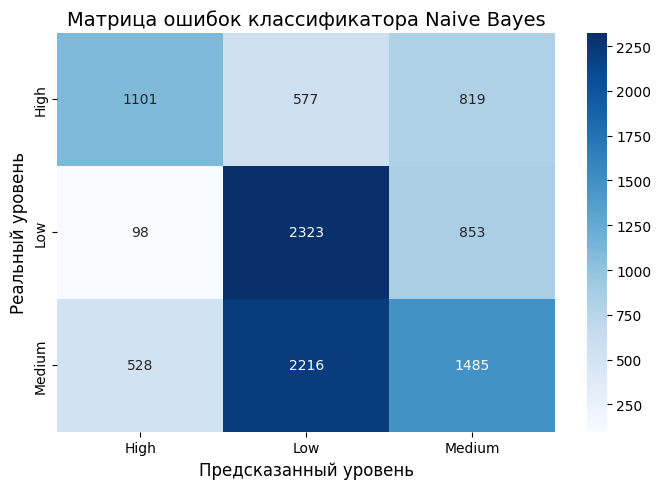


Интерпретация результатов
   High: правильно предсказано 1101/2497 (44.1%)
   Low: правильно предсказано 2323/3274 (71.0%)
   Medium: правильно предсказано 1485/4229 (35.1%)


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")


# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")

# Baseline (случайное угадывание)
baseline = np.max(np.bincount(y_test)) / len(y_test)
print(f"Baseline (угадывание частого класса): {baseline:.4f} ({baseline*100:.2f}%)")

# Улучшение
improvement = ((accuracy - baseline) / baseline) * 100
print(f"Модель лучше baseline на: {improvement:.1f}%")

# Детальный отчёт по классам
print("\nОтчёт по каждому классу")
print(classification_report(y_test, y_pred, target_names=le_y.classes_))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_y.classes_,
            yticklabels=le_y.classes_)
plt.xlabel('Предсказанный уровень', fontsize=12)
plt.ylabel('Реальный уровень', fontsize=12)
plt.title('Матрица ошибок классификатора Naive Bayes', fontsize=14)
plt.tight_layout()
plt.savefig('C:/Users/Redmi/Desktop/practise2026/data/result/confusion_matrix.png', dpi=300)
plt.show()

# Интерпретация по классам
print("\nИнтерпретация результатов")
for i, class_name in enumerate(le_y.classes_):
    correct = cm[i, i]
    total = np.sum(cm[i, :])
    print(f"   {class_name}: правильно предсказано {correct}/{total} ({correct/total*100:.1f}%)")


In [12]:

print("ЭКСПОРТ ДАННЫХ ДЛЯ POWER BI")


#датафрейм для Power BI
df_powerbi = X.copy()
df_powerbi['Burnout_Risk_Level'] = le_y.inverse_transform(y_encoded)
df_powerbi['Burnout_Code'] = y_encoded

#текстовые значения для фильтров
df_powerbi['Major_Category'] = df['Major_Category']
df_powerbi['Year_of_Study'] = df['Year_of_Study']
df_powerbi['Institutional_Policy'] = df['Institutional_Policy']

os.makedirs('../data/processed', exist_ok=True)
df_powerbi.to_csv('C:/Users/Redmi/Desktop/practise2026/data/processed/ai_data_for_powerbi.csv', index=False)

print(f"Данные сохранены в 'data/processed/ai_data_for_powerbi.csv'")
print(f"   Размер: {df_powerbi.shape[0]} строк, {df_powerbi.shape[1]} столбцов")
print(f"   Столбцы: {', '.join(df_powerbi.columns.tolist())}")


ЭКСПОРТ ДАННЫХ ДЛЯ POWER BI
Данные сохранены в 'data/processed/ai_data_for_powerbi.csv'
   Размер: 50000 строк, 12 столбцов
   Столбцы: Weekly_GenAI_Hours, Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity, Traditional_Study_Hours, Perceived_AI_Dependency, Institutional_Policy, Anxiety_Level_During_Exams, Major_Category, Year_of_Study, Burnout_Risk_Level, Burnout_Code
